## Punto 2 - Vegetable Image Dataset

Tenemos **21,000 fotos de vegetales** divididas en **15 tipos**.
El trabajo es: imaginar que NO sabemos qué vegetal es cada foto,
usar KMeans para agruparlas, y etiquetar solo las más representativas.
**Carpetas usadas:**
- **train/** para entrenar el modelo (15,000 imágenes)
- **test/**  para evaluar el modelo  (3,000 imágenes)



### Paso 1 — Cargar las librerías que vamos a usar

In [78]:
import os                          # para leer carpetas del disco
import numpy as np                 # para trabajar con números y arrays
import matplotlib.pyplot as plt    # para hacer gráficas
from PIL import Image              # para abrir imágenes
from sklearn.cluster import KMeans # el algoritmo KMeans
from sklearn.linear_model import LogisticRegression  # el clasificador


### Paso 2 — Conectar Google Drive

In [79]:
# Esto conecta tu Google Drive con Colab
# para que podamos leer el dataset que subiste ahí
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Paso 3 — Decirle al código dónde están las carpetas

In [80]:
# Ruta de la carpeta TRAIN (donde están las imágenes para entrenar)
CARPETA_ENTRENAMIENTO = '/content/drive/MyDrive/Colab Notebooks/Intelegencia Artificial/Dataset/Vegetable Images/train'

# Ruta de la carpeta TEST (donde están las imágenes para evaluar)
CARPETA_PRUEBA = '/content/drive/MyDrive/Colab Notebooks/Intelegencia Artificial/Dataset/Vegetable Images/test'

# Verificar que las carpetas existen
print('¿Existe carpeta train?:', os.path.exists(CARPETA_ENTRENAMIENTO))
print('¿Existe carpeta test? :', os.path.exists(CARPETA_PRUEBA))


¿Existe carpeta train?: True
¿Existe carpeta test? : True


### Paso 4 — Leer los nombres de los 15 vegetales

In [81]:
# Cada subcarpeta dentro de train/ es un tipo de vegetal
# sorted() los ordena alfabéticamente para que siempre queden igual
CLASES = sorted(os.listdir(CARPETA_ENTRENAMIENTO))

# Traducción al español (solo para mostrar en pantalla)
TRADUCCION = {
    'Bean'        : 'Frijol',
    'Bitter_Gourd': 'Melon amargo',
    'Bottle_Gourd': 'Calabaza larga',
    'Brinjal'     : 'Berenjena',
    'Broccoli'    : 'Brocoli',
    'Cabbage'     : 'Repollo',
    'Capsicum'    : 'Pimiento',
    'Carrot'      : 'Zanahoria',
    'Cauliflower' : 'Coliflor',
    'Cucumber'    : 'Pepino',
    'Papaya'      : 'Papaya',
    'Potato'      : 'Papa',
    'Pumpkin'     : 'Zapallo',
    'Radish'      : 'Rabano',
    'Tomato'      : 'Tomate'
}

print('Vegetales encontrados:')
for i, clase in enumerate(CLASES):
    print(f'  Clase {i:2d} = {TRADUCCION[clase]}')

print()
print('Total de clases:', len(CLASES))


Vegetales encontrados:
  Clase  0 = Frijol
  Clase  1 = Melon amargo
  Clase  2 = Calabaza larga
  Clase  3 = Berenjena
  Clase  4 = Brocoli
  Clase  5 = Repollo
  Clase  6 = Pimiento
  Clase  7 = Zanahoria
  Clase  8 = Coliflor
  Clase  9 = Pepino
  Clase 10 = Papaya
  Clase 11 = Papa
  Clase 12 = Zapallo
  Clase 13 = Rabano
  Clase 14 = Tomate

Total de clases: 15


### Paso 5 — Cargar las imágenes

Cada imagen se convierte a un listado de números (píxeles).
Una imagen de 64x64 con colores RGB = 64 × 64 × 3 = **12,288 números**.
Eso es una fila de la matriz X.


In [82]:
def cargar_imagenes(carpeta):
    imagenes  = []
    etiquetas = []

    for numero_clase, nombre_clase in enumerate(CLASES):
        ruta_clase = os.path.join(carpeta, nombre_clase)

        for archivo in os.listdir(ruta_clase):
            if not archivo.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            ruta_imagen = os.path.join(ruta_clase, archivo)
            img     = Image.open(ruta_imagen).convert('RGB').resize((64, 64))
            pixeles = np.array(img, dtype=np.float32) / 255.0
            imagenes.append(pixeles.flatten())
            etiquetas.append(numero_clase)

    X = np.array(imagenes)
    y = np.array(etiquetas)

    # ── MEZCLAR aleatoriamente ──────────────────────────────
    # IMPORTANTE: sin esto, X_train[:1000] serían solo imágenes
    # de la primera carpeta (Bean), porque las carpetas se cargan
    # en orden alfabético: primero todas las de Bean, luego
    # todas las de Bitter_Gourd, etc.
    # permutation() genera índices mezclados aleatoriamente
    # para que los 1000 primeros tengan todos los vegetales.
    indices_mezclados = np.random.RandomState(42).permutation(len(X))
    return X[indices_mezclados], y[indices_mezclados]


In [83]:
print('Cargando imágenes de entrenamiento...')
X_train, y_train = cargar_imagenes(CARPETA_ENTRENAMIENTO)
print(f'  {X_train.shape[0]} imágenes | {X_train.shape[1]} píxeles por imagen')

print()
print('Cargando imágenes de prueba...')
X_test, y_test = cargar_imagenes(CARPETA_PRUEBA)
print(f'  {X_test.shape[0]} imágenes | {X_test.shape[1]} píxeles por imagen')

print()
print('Imágenes por vegetal (entrenamiento):')
for i, clase in enumerate(CLASES):
    cantidad = (y_train == i).sum()
    print(f'  {TRADUCCION[clase]:<20}: {cantidad} imágenes')


Cargando imágenes de entrenamiento...
  15000 imágenes | 12288 píxeles por imagen

Cargando imágenes de prueba...
  3000 imágenes | 12288 píxeles por imagen

Imágenes por vegetal (entrenamiento):
  Frijol              : 1000 imágenes
  Melon amargo        : 1000 imágenes
  Calabaza larga      : 1000 imágenes
  Berenjena           : 1000 imágenes
  Brocoli             : 1000 imágenes
  Repollo             : 1000 imágenes
  Pimiento            : 1000 imágenes
  Zanahoria           : 1000 imágenes
  Coliflor            : 1000 imágenes
  Pepino              : 1000 imágenes
  Papaya              : 1000 imágenes
  Papa                : 1000 imágenes
  Zapallo             : 1000 imágenes
  Rabano              : 1000 imágenes
  Tomate              : 1000 imágenes


### Paso 6 — Ver una imagen de cada vegetal

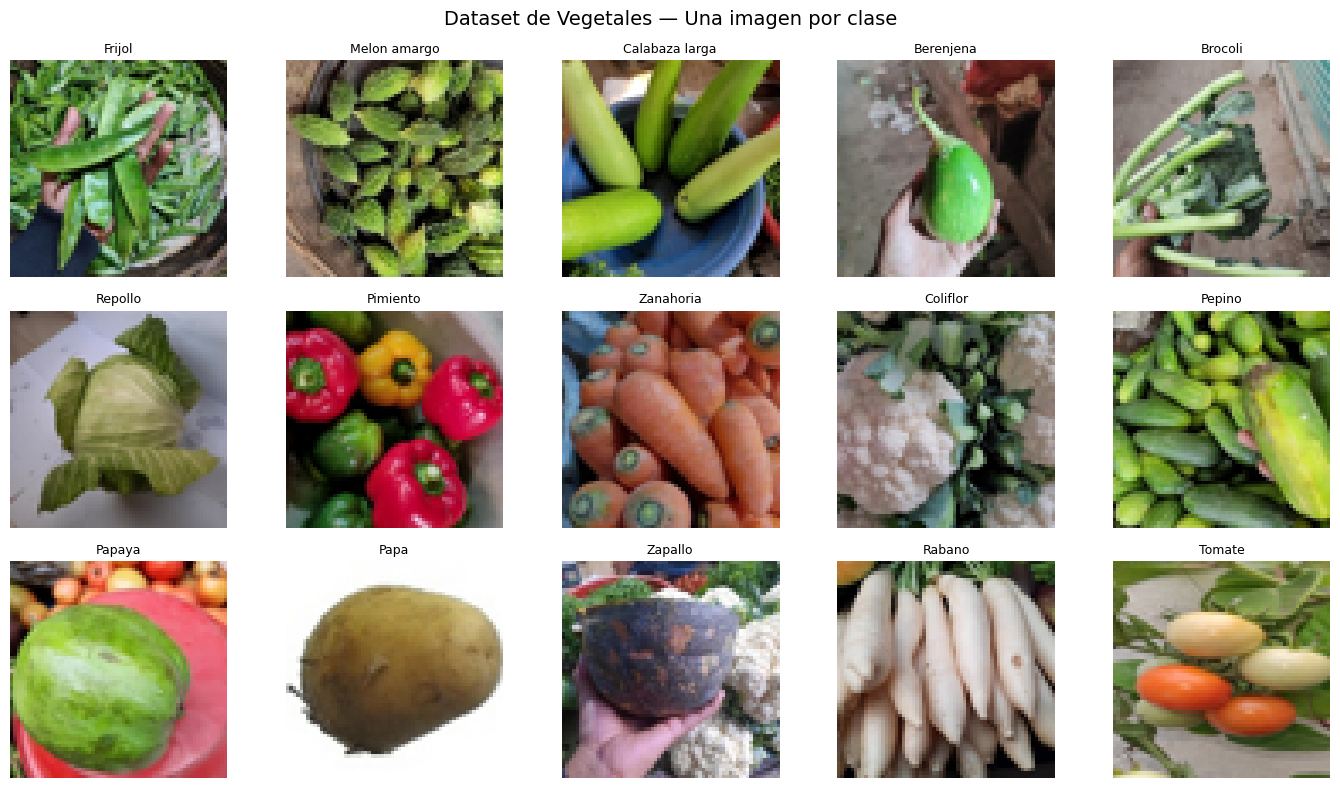

In [84]:
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle('Dataset de Vegetales — Una imagen por clase', fontsize=14)

for i, clase in enumerate(CLASES):
    fila    = i // 5   # en qué fila de la cuadrícula va
    columna = i % 5    # en qué columna va

    # Buscar la primera imagen de este vegetal
    indices = np.where(y_train == i)[0]
    img     = X_train[indices[0]].reshape(64, 64, 3)

    axes[fila, columna].imshow(img)
    axes[fila, columna].set_title(TRADUCCION[clase], fontsize=9)
    axes[fila, columna].axis('off')

plt.tight_layout()
plt.show()


### K-Means para aprendizaje semi-supervisado.

El aprendizaje semi-supervisado (o *Semi-supervised Learning*) comprende el conjunto
de tecnicas que nos permiten entrenar modelos con datasets parcialmente etiquetados.

**La idea completa:**
1. Imaginamos que NO sabemos qué vegetal es cada imagen
2. KMeans agrupa las 15,000 imágenes en 100 grupos por similitud visual
3. De cada grupo tomamos la imagen más cercana al centro = la más representativa
4. Etiquetamos solo esas 100 imágenes (en vez de las 15,000)
5. Entrenamos un clasificador con esas 50 imágenes
6. Comparamos con elegir 50 imágenes al azar


In [85]:
from sklearn.cluster import KMeans

# Usamos 100 grupos aunque haya 15 clases
# ¿Por qué 50 y no 15?
# Porque dentro de "Zanahoria" hay fotos con distintos ángulos,
# iluminaciones, tamaños... 50 grupos captura mejor esa variedad.
k = 80
kmeans = KMeans(n_clusters=k, random_state=42)

# fit_transform hace dos cosas a la vez:
# 1. Agrupa las 15,000 imágenes en 50 grupos (fit)
# 2. Calcula la distancia de cada imagen a cada uno de los 50 centros (transform)
X_digits_dist = kmeans.fit_transform(X_train)



In [86]:
# X_digits_dist tiene:
# - una fila por imagen (15,000 filas)
# - una columna por grupo (100 columnas)
# - cada número = distancia de esa imagen a ese centro
print(X_digits_dist.shape)
print(X_digits_dist)


(15000, 80)
[[51.063374 30.006512 36.266376 ... 51.92354  50.785427 51.00921 ]
 [31.214151 43.02315  42.543037 ... 33.47895  27.662683 32.585587]
 [38.303722 36.99393  32.520996 ... 26.997643 38.42341  36.789886]
 ...
 [22.611675 33.500446 36.17672  ... 28.332626 19.509306 28.052176]
 [26.16968  37.385677 35.35777  ... 25.805773 22.26463  27.764042]
 [27.237503 38.66413  36.35181  ... 25.374151 26.70435  28.472733]]


In [87]:
# argmin busca el índice del valor MÁS PEQUEÑO en cada columna
# columna = un grupo → el valor más pequeño = la imagen MÁS CERCANA al centro
# = la imagen más REPRESENTATIVA de ese grupo
idxs = np.argmin(X_digits_dist, axis=0)

# Con esos índices, sacamos las 50 imágenes más representativas
X_representative_digits = X_train[idxs]


In [88]:
print(X_representative_digits.shape)
print(X_representative_digits)


(80, 12288)
[[0.24313726 0.4117647  0.16078432 ... 0.4117647  0.50980395 0.31764707]
 [0.74509805 0.7411765  0.72156864 ... 0.60784316 0.6117647  0.6039216 ]
 [0.49019608 0.4862745  0.47843137 ... 0.6039216  0.60784316 0.6156863 ]
 ...
 [0.44313726 0.4862745  0.5137255  ... 0.3647059  0.3647059  0.3647059 ]
 [0.5921569  0.6666667  0.41960785 ... 0.21960784 0.1764706  0.08627451]
 [0.49411765 0.4745098  0.47058824 ... 0.6666667  0.6392157  0.5137255 ]]


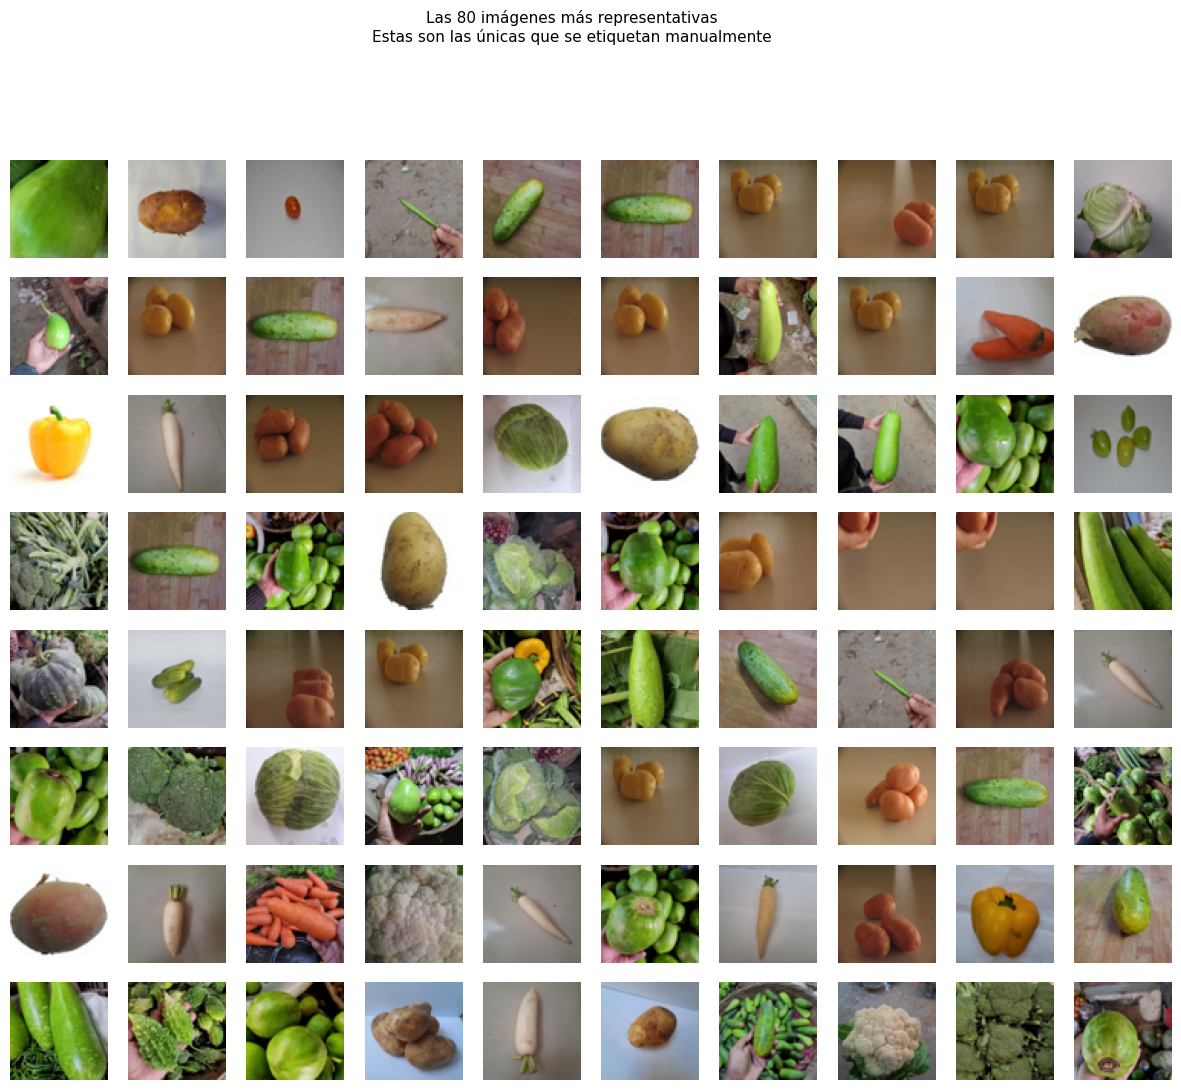

In [100]:
# Mostrar las 50 imágenes más representativas
plt.figure(figsize=(15, 15))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(64, 64, 3))
    plt.axis('off')
plt.suptitle('Las 80 imágenes más representativas\n'
             'Estas son las únicas que se etiquetan manualmente', fontsize=11)
plt.show()


El siguiente paso consiste en anotar manualmente estas etiquetas (aquí haremos trampas ya que disponemos de dichas etiquetas :p).

In [90]:
# Obtener las etiquetas REALES de esas 100 imágenes representativas
# En la vida real, aquí un experto miraría cada foto y la etiquetaría
# Nosotros "hacemos trampa" usando y_train que ya tiene las etiquetas
y_representative_digits = y_train[idxs]
print(y_representative_digits)

[10 11 14  0  9  9 11 11 11  5  3 11  9 13 11 11  2 11  7 11  6 13 11 11
  5 11  2  2 10 14  4  9 10 11  5 10 11 11 11  2 12  9 11 11  6  2  9  0
 11 13 10  4  5  3  5 11  5 11  9  3 11 13  7  8 13 10 13 11  6  9  2  1
 10 11 13 11  9  8  4 10]


Y entrenaremos un clasificador usando estas imágenes representativas.

In [91]:
from sklearn.linear_model import LogisticRegression

# Entrenar con las 50 imágenes REPRESENTATIVAS elegidas por KMeans
log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits, y_representative_digits)
log_reg2.score(X_test, y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 12.6 s, sys: 16.7 ms, total: 12.6 s
Wall time: 6.57 s


0.23466666666666666

Como puedes observar hemos obtenido una precision habiendo anotado simplemente 100 imagenes, pero aquellas mas representativas. Entrenar el mismo modelo con las primeras 100 imagenes (aleatorias) nos dara una precision menor.

In [92]:
# Entrenar con las primeras 100 imágenes del dataset (aleatorias)
# Esto es el BASELINE — lo mínimo que esperamos obtener
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg.fit(X_train[:100], y_train[:100])
log_reg.score(X_test, y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 18 s, sys: 21.7 ms, total: 18.1 s
Wall time: 10.3 s


0.31133333333333335

A veces, al entrenar modelos de Machine Learning, no importa tanto tener muchos datos, sino que sean los mas utiles y representativos.
Podemos propagar las etiquetas al resto del dataset: cada imagen recibe la etiqueta de la imagen representativa de su grupo (centroide más cercano).

In [93]:
# Crear un array vacío del mismo tamaño que y_train
y_train_propagated = np.empty(len(X_train), dtype=int)

# Para cada uno de los 100 grupos:
# todas las imágenes de ese grupo reciben la etiqueta
# de su imagen representativa
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

# Ahora TODAS las 15,000 imágenes tienen una etiqueta asignada
# (aunque sea heredada de su representante, no etiquetada manualmente)
print('Etiquetas propagadas a', len(y_train_propagated), 'imágenes')


Etiquetas propagadas a 15000 imágenes


In [94]:
# Entrenar con las primeras 1,000 imágenes usando etiquetas propagadas
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg3.fit(X_train[:1000], y_train_propagated[:1000])
log_reg3.score(X_test, y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 1min 47s, sys: 127 ms, total: 1min 47s
Wall time: 1min 2s


0.16066666666666668

Esto sin embargo puede empeorar nuestro clasificador, incluso usando mas muestras de entrenamiento. Esto es debido al ruido que estamos introduciendo, ya que no todas las imagenes estaran bien agrupadas. Para mejorar esto podemos aplicar tecnicas de aprendizaje activo.

### Aprendizaje Activo

El aprendizaje activo (o *Active Learning*) consiste en entrenar modelos de ML de manera iterativa, incluyendo en cada iteracion nuevas muestras al dataset focalizando en ejemplos en los que el modelo tenga mas problemas.

In [95]:
# predict_proba dice con qué confianza el modelo clasifica cada imagen
# Por ejemplo: [0.02, 0.71, 0.03, ...] → 71% seguro de que es clase 1
probas = log_reg3.predict_proba(X_train[:1000])
# argmax encuentra la clase con mayor probabilidad (la que predice)
labels_ixs = np.argmax(probas, axis=1)

# Extraer la probabilidad de la clase predicha para cada imagen
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])

# argsort ordena de menor a mayor confianza
# las primeras posiciones = imágenes donde el modelo está más confundido
sorted_ixs = np.argsort(labels)

# Ver las 10 confianzas más bajas
labels[sorted_ixs[:10]]


array([0.76164647, 0.77690448, 0.81818193, 0.81879302, 0.831176  ,
       0.83280197, 0.84551862, 0.85380023, 0.85526457, 0.85963151])

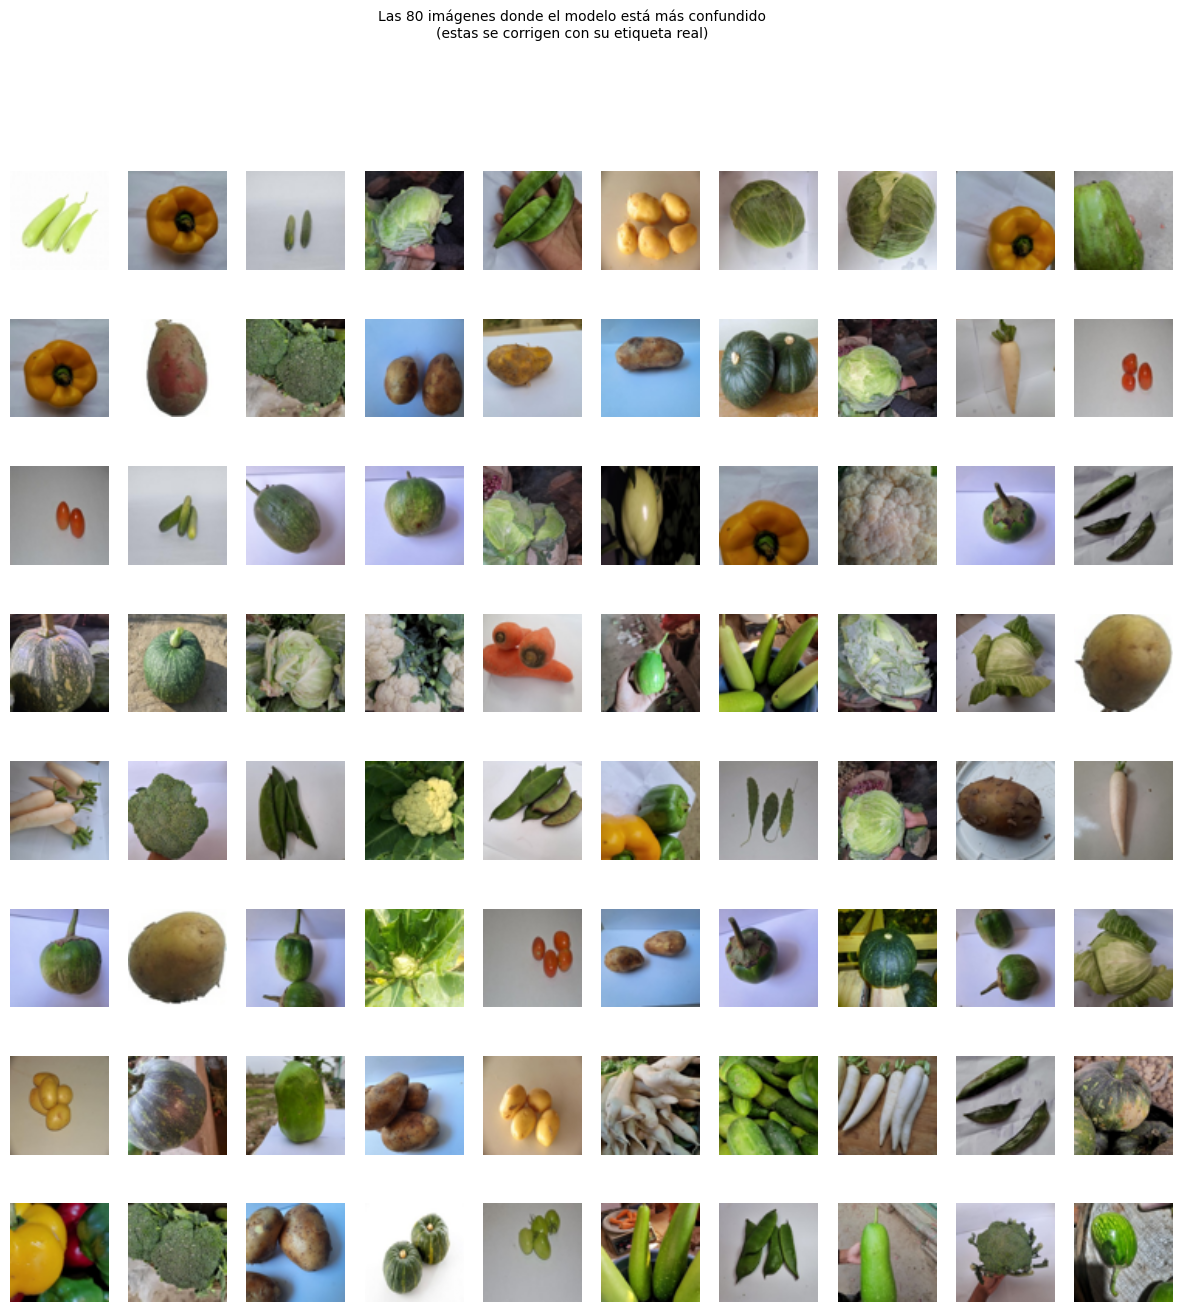

In [96]:
# Tomar las 100 imágenes donde el modelo tiene MENOS confianza
X_lowest = X_train[:1000][sorted_ixs[:k]]

plt.figure(figsize=(15, 15))
for index, img in enumerate(X_lowest):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(img.reshape(64, 64, 3), interpolation="bilinear")
    plt.axis('off')
plt.suptitle(f'Las {k} imágenes donde el modelo está más confundido\n'
             '(estas se corrigen con su etiqueta real)', fontsize=10)
plt.show()


In [97]:
# Obtener las etiquetas REALES de esas 50 imágenes confusas
# En la vida real, aquí un experto las etiquetaría manualmente
y_lowest = y_train[:1000][sorted_ixs[:k]]
y_lowest


array([ 2,  6,  9,  5,  0, 11,  5,  5,  6, 10,  6, 11,  4, 11, 11, 11, 12,
        5, 13, 14, 14,  9,  3,  3,  5, 14,  6,  8,  3,  0, 12, 12,  5,  8,
        7,  3,  2,  5,  5, 11, 13,  4,  0,  8,  0,  6,  1,  5, 11, 13,  3,
       11,  3,  8, 14, 11,  3, 12,  3,  5, 11, 12, 10, 11, 11, 13,  9, 13,
        0, 12,  6,  4, 11, 12, 14,  2,  0,  2,  4,  3])

In [98]:
# Copiar las etiquetas propagadas
y_train2 = y_train_propagated[:1000].copy()

# Reemplazar las 50 más confusas con sus etiquetas REALES
# Esto es lo que hace el aprendizaje activo:
# corregir exactamente donde el modelo más lo necesita
y_train2[sorted_ixs[:k]] = y_lowest


In [99]:
# Reentrenar con las correcciones aplicadas
log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg5.fit(X_train[:1000], y_train2)
log_reg5.score(X_test, y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 1min 35s, sys: 104 ms, total: 1min 35s
Wall time: 53.7 s


0.17433333333333334